# Module 11 — Bayesian A/B Testing

Part of the **A/B Testing Playbook** learning program — an extension beyond the original 10-module curriculum, added 2026-09-18 after an honest self-critique. Full program context: see `CURRICULUM.md`.

## From the curriculum

> **Concepts**
> - Prior, likelihood, posterior — the Bayesian update, in plain terms
> - The Beta-Binomial conjugate model for conversion-rate tests — closed-form, no heavy machinery needed
> - Probability that B beats A, and credible intervals — the Bayesian answers to "is it significant" and "what's the CI"
> - Contrasting the same result under frequentist vs. Bayesian framing — where they agree, where the interpretation genuinely differs
>
> **Why it matters**
> Frequentist and Bayesian are two different, both legitimate lenses on the same data. Knowing why "there's a 95% probability B is better" (Bayesian) is a different claim from "p = 0.05" (frequentist) — even though the numbers invite reading them as complements of each other, they're not — is a common interview differentiator, and Bayesian methods are used in real experimentation platforms.
>
> **Worked example**
> The same checkout-test numbers from Module 3, analyzed both ways: the frequentist z-test/CI (already built), and a Beta-Binomial Bayesian analysis on the identical data — probability B beats A, and a 95% credible interval — compared side by side.
>
> **Resources**
> - [Bayesian Statistics for A/B Testing Explained](https://www.growthbook.io/insights/bayesian-statistics) — GrowthBook (verified, ~10-12 min)
> - [Formulas for Bayesian A/B Testing](https://www.evanmiller.org/bayesian-ab-testing.html) — Evan Miller (verified, ~15-20 min, calculus-heavy; skip to the implementation section if that's not your thing)
>
> **Exercise type:** computational — implement the Beta-Binomial update from scratch, compute probability-to-beat and a credible interval, contrast with the frequentist read on the same data.
>
> **Interview angle:** "explain Bayesian vs. frequentist A/B testing" / "what does '95% probability B is better' actually mean."

## Lesson

### What "frequentist" even means

Every module before this one — Module 3's z-test, CI, everything — was **frequentist** statistics; there was just no need for the label until now, with a second framework to contrast it against. Frequentist statistics defines probability as *long-run frequency over repeated trials*: a p-value and a CI are both statements about what would happen if you repeated the exact same experiment many times. It treats the true effect as a fixed, unknown constant, and the data as the random part. **Bayesian** statistics flips that: it treats the true effect itself as uncertain -- something you assign a range of plausible values to -- and updates that range using the one dataset you actually have.

### Prior, likelihood, posterior

Bayesian inference updates an *estimate* using data -- and it does this **separately for each group**: control gets its own update, treatment gets its own, completely independent update. For one group: you start with a **prior** (an assumption about that group's true rate before its data), observe data with a **likelihood** (how probable that data is, for each possible true rate), and combine them into a **posterior** (updated estimate, now informed by data). Do this once for control, once for treatment -- two independent updates, not one process split across the two groups. ("A" and "B" are simply control and treatment, same as every other module -- unrelated to prior/posterior, which describes *before* vs. *after* within one group's own update.)

### The Beta-Binomial conjugate model

For a conversion rate (a "did they convert, yes/no" outcome), the **Beta distribution** is the natural choice of prior -- it's defined on exactly [0, 1], the same range a rate lives in. Written `Beta(alpha, beta)`: "Beta" (capitalized) names the distribution family itself; `alpha` and `beta` (lowercase) are just its two parameters, not a second distribution -- easy to conflate since they share a name. The two parameters have a direct, intuitive reading: think of them as "prior successes" and "prior failures" -- a `Beta(1, 1)` prior is flat (equivalent to having seen 1 prior success and 1 prior failure, i.e. no real information), while a `Beta(250, 4750)` prior is a strong assumption centered at `250/(250+4750) = 5%`.

The update rule, once you observe `x` successes out of `n` trials, is remarkably simple: **posterior = Beta(prior_alpha + x, prior_beta + (n - x))**. Successes just get added to `alpha`, failures to `beta`. This isn't a coincidence or a special trick for this case -- Beta is called the *conjugate prior* for exactly this kind of data because the update always stays inside the Beta family, so it never requires the heavy numerical integration Bayesian methods generally need.

### Probability B beats A

With control's own posterior and treatment's own posterior in hand -- two separate results from two separate updates -- "probability B beats A" compares them: repeatedly draw one plausible true rate from each posterior, check which is bigger, and see how often treatment wins. Do this enough times and the fraction converges to the actual probability -- no closed-form formula required to trust it, since it's a direct simulation of exactly what the phrase means.

### Credible intervals vs. confidence intervals

This is the payoff for everything Module 9 fought through. A 95% **credible interval** means, literally: *"given this data and this prior, there's a 95% probability the true value falls in this range."* That's exactly the sentence everyone *wants* a frequentist CI to mean -- and, as Module 9 established at length, isn't actually what a frequentist CI means (a frequentist CI's guarantee is about the *procedure*, over repeated sampling, not a probability statement about this one true value). The Bayesian credible interval earns the intuitive reading the frequentist CI never quite gives you -- at a real cost: the prior gets mathematically fused into the final answer, literally added into `alpha`/`beta`. A frequentist calculation can also lean on an assumed baseline rate (Module 3's sample-size formula needs one) -- but only for upfront planning; it's never combined into the final test's math once real data exists, the way a Bayesian prior is.

### An honest caveat: not a free lunch

Two things worth knowing rather than assuming: **the prior is a real, contestable choice** -- a strongly opinionated prior can meaningfully shift the conclusion, and Part 3 shows this concretely, not just asserts it. And **Bayesian methods are not automatically immune to Module 5's peeking problem** -- repeatedly checking a posterior probability and stopping the moment it crosses a threshold has its own version of the same risk; genuinely "always-valid" Bayesian monitoring requires a deliberately designed stopping rule, not just "Bayesian" as a label. Treat any claim that Bayesian testing simply solves peeking for free with the same skepticism this program has applied to every other big claim.

### Part 1 — The Beta-Binomial update, on Module 3's exact data

Reusing Module 3's own worked-example numbers (control: 1,005/20,000, treatment: 1,095/20,000) so the frequentist and Bayesian results can be compared on identical data, not two different examples. Same caveat as Module 3: these are hand-chosen fixed facts, not randomly generated -- treated here as "what the experiment actually produced," the input both frequentist and Bayesian analysis then process differently.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GOOD = "#1a7f37"
BAD = "#cf222e"
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

x1_obs, n1_obs = 1005, 20_000  # control (Module 3's exact worked example)
x2_obs, n2_obs = 1095, 20_000  # treatment

# flat, uninformative prior: Beta(1, 1)
prior_alpha, prior_beta = 1, 1

alpha_c, beta_c = prior_alpha + x1_obs, prior_beta + (n1_obs - x1_obs)
alpha_t, beta_t = prior_alpha + x2_obs, prior_beta + (n2_obs - x2_obs)

print(f"Prior used (same for both groups): Beta({prior_alpha}, {prior_beta}) -- flat/uninformative, "
      f"equivalent to having already seen just 1 prior success and 1 prior failure, i.e. no real information")
print(f"Posterior, control:   Beta({alpha_c}, {beta_c})   = prior Beta({prior_alpha},{prior_beta}) + {x1_obs} successes, {n1_obs-x1_obs} failures")
print(f"Posterior, treatment: Beta({alpha_t}, {beta_t})   = prior Beta({prior_alpha},{prior_beta}) + {x2_obs} successes, {n2_obs-x2_obs} failures")

Prior used (same for both groups): Beta(1, 1) -- flat/uninformative, equivalent to having already seen just 1 prior success and 1 prior failure, i.e. no real information
Posterior, control:   Beta(1006, 18996)   = prior Beta(1,1) + 1005 successes, 18995 failures
Posterior, treatment: Beta(1096, 18906)   = prior Beta(1,1) + 1095 successes, 18905 failures


In [2]:
n_samples = 2_000_000
samples_c = rng.beta(alpha_c, beta_c, n_samples)
samples_t = rng.beta(alpha_t, beta_t, n_samples)

prob_beats = (samples_t > samples_c).mean()  # direct simulation of the definition
diff_samples = samples_t - samples_c
cred_lo, cred_hi = np.percentile(diff_samples, [2.5, 97.5])

print(f"P(treatment beats control) = {prob_beats:.1%}  (from {n_samples:,} simulated draws)")
print(f"95% credible interval on the difference: ({cred_lo*100:+.3f}pp, {cred_hi*100:+.3f}pp)")
print(f"Posterior mean difference: {diff_samples.mean()*100:+.3f}pp")

P(treatment beats control) = 97.8%  (from 2,000,000 simulated draws)
95% credible interval on the difference: (+0.012pp, +0.888pp)
Posterior mean difference: +0.450pp


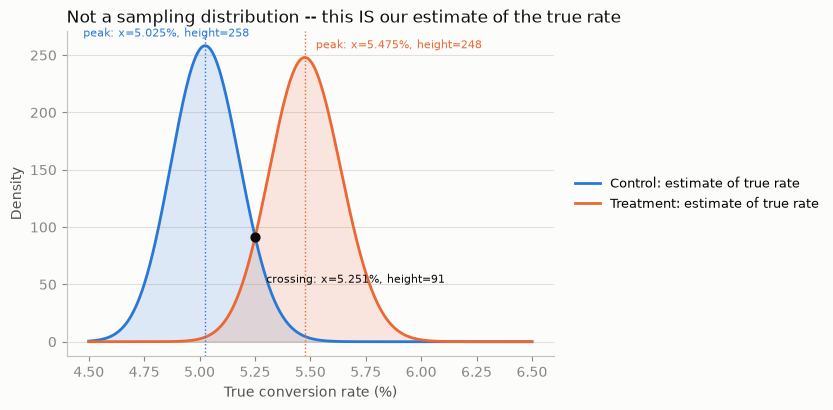

In [3]:
from scipy.optimize import brentq

x = np.linspace(0.045, 0.065, 500)
pdf_c = stats.beta.pdf(x, alpha_c, beta_c)  # the Beta posterior's actual density
pdf_t = stats.beta.pdf(x, alpha_t, beta_t)

# exact reference points, computed (not eyeballed): each curve's peak, and where they cross
mode_c = (alpha_c - 1) / (alpha_c + beta_c - 2)
mode_t = (alpha_t - 1) / (alpha_t + beta_t - 2)
peak_c = stats.beta.pdf(mode_c, alpha_c, beta_c)
peak_t = stats.beta.pdf(mode_t, alpha_t, beta_t)
x_cross = brentq(lambda v: stats.beta.pdf(v, alpha_c, beta_c) - stats.beta.pdf(v, alpha_t, beta_t), mode_c, mode_t)
y_cross = stats.beta.pdf(x_cross, alpha_c, beta_c)

fig, ax = plt.subplots(figsize=(7.5, 4.4), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot(x * 100, pdf_c, color=BLUE, linewidth=2, label="Control: estimate of true rate")
ax.fill_between(x * 100, pdf_c, color=BLUE, alpha=0.15)
ax.plot(x * 100, pdf_t, color=ORANGE, linewidth=2, label="Treatment: estimate of true rate")
ax.fill_between(x * 100, pdf_t, color=ORANGE, alpha=0.15)

# mark and label the three reference points explicitly, with their exact coordinates
ax.axvline(mode_c * 100, color=BLUE, linewidth=1, linestyle=":")
ax.annotate(f"peak: x={mode_c*100:.3f}%, height={peak_c:.0f}", xy=(mode_c * 100, peak_c),
            xytext=(mode_c * 100 - 0.55, peak_c + 8), fontsize=8, color=BLUE)
ax.axvline(mode_t * 100, color=ORANGE, linewidth=1, linestyle=":")
ax.annotate(f"peak: x={mode_t*100:.3f}%, height={peak_t:.0f}", xy=(mode_t * 100, peak_t),
            xytext=(mode_t * 100 + 0.05, peak_t + 8), fontsize=8, color=ORANGE)
ax.scatter([x_cross * 100], [y_cross], color=INK, s=40, zorder=5)
ax.annotate(f"crossing: x={x_cross*100:.3f}%, height={y_cross:.0f}", xy=(x_cross * 100, y_cross),
            xytext=(x_cross * 100 + 0.05, y_cross - 40), fontsize=8, color=INK)

ax.set_xlabel("True conversion rate (%)", color=INK_SECONDARY)
ax.set_ylabel("Density", color=INK_SECONDARY)
ax.set_title("Not a sampling distribution -- this IS our estimate of the true rate", color=INK, fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)
ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8)
ax.set_axisbelow(True)

fig.subplots_adjust(left=0.09, right=0.74, top=0.88, bottom=0.14)
ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.show()

In [4]:
print("Control (blue):")
print(f"  mode_c = (alpha_c - 1) / (alpha_c + beta_c - 2) = ({alpha_c}-1) / ({alpha_c}+{beta_c}-2) "
      f"= {alpha_c-1} / {alpha_c+beta_c-2} = {mode_c:.5f} = {mode_c*100:.3f}%")
print(f"  peak_c = beta.pdf(mode_c, alpha_c, beta_c) = beta.pdf({mode_c*100:.3f}%, {alpha_c}, {beta_c}) = {peak_c:.2f}")

print()
print("Treatment (orange):")
print(f"  mode_t = (alpha_t - 1) / (alpha_t + beta_t - 2) = ({alpha_t}-1) / ({alpha_t}+{beta_t}-2) "
      f"= {alpha_t-1} / {alpha_t+beta_t-2} = {mode_t:.5f} = {mode_t*100:.3f}%")
print(f"  peak_t = beta.pdf(mode_t, alpha_t, beta_t) = beta.pdf({mode_t*100:.3f}%, {alpha_t}, {beta_t}) = {peak_t:.2f}")

Control (blue):
  mode_c = (alpha_c - 1) / (alpha_c + beta_c - 2) = (1006-1) / (1006+18996-2) = 1005 / 20000 = 0.05025 = 5.025%
  peak_c = beta.pdf(mode_c, alpha_c, beta_c) = beta.pdf(5.025%, 1006, 18996) = 258.25

Treatment (orange):
  mode_t = (alpha_t - 1) / (alpha_t + beta_t - 2) = (1096-1) / (1096+18906-2) = 1095 / 20000 = 0.05475 = 5.475%
  peak_t = beta.pdf(mode_t, alpha_t, beta_t) = beta.pdf(5.475%, 1096, 18906) = 248.00


**What this shows:** unlike Module 3's H0/H1 chart (two *hypothetical sampling distributions*, one assuming no effect, one assuming an assumed effect size, neither one "the truth"), these two curves are direct estimates of where each group's *actual* true conversion rate lies, given the data actually observed. Their separation, and how much they overlap, is visually where "probability treatment beats control" (97.8%) comes from — most of the orange curve's mass sits to the right of most of the blue curve's mass, but there's real overlap, which is exactly why the probability isn't 100%.

### Part 2 — Frequentist vs. Bayesian, side by side, same data

Module 3's frequentist result on this exact data: z = 2.018, p = 0.0436, 95% CI (0.013pp, 0.887pp).

In [5]:
import pandas as pd

comparison = pd.DataFrame({
    "Frequentist (Module 3)": ["p = 0.0436 (just under 0.05)", "95% CI: (0.013pp, 0.887pp)", "\"Reject H0 at the 5% level\""],
    "Bayesian (this module)": [f"P(treatment beats control) = {prob_beats:.1%}", f"95% credible interval: ({cred_lo*100:+.3f}pp, {cred_hi*100:+.3f}pp)", "\"97.8% probability the true effect is positive\""],
}, index=["Headline number", "Interval", "Plain-language claim"])
comparison

,Frequentist (Module 3),Bayesian (this module)
Headline number,p = 0.0436 (just under 0.05),P(treatment beats control) = 97.8%
Interval,"95% CI: (0.013pp, 0.887pp)","95% credible interval: (+0.012pp, +0.888pp)"
Plain-language claim,"""Reject H0 at the 5% level""","""97.8% probability the true effect is positive"""


**What this shows:** the two intervals are numerically very close here (0.013 to 0.887 vs. 0.012 to 0.888) — expected with a flat prior and a large sample, where the prior barely influences the answer and the two frameworks converge. But **that closeness is not a mathematical identity** — a common misconception is treating `1 - p` as if it equals the Bayesian probability of a real effect (`0.9564` vs. the actual `0.978` here); they're related but genuinely different quantities computed from different frameworks, and they only stay this close under a weak prior and reasonably large data. The real difference isn't the numbers here — it's the plain-language claim each framework is actually entitled to make (Module 9's whole lesson: what a number is allowed to mean, not just what it is).

### Part 3 — Prior sensitivity: not a free lunch

Same data, a deliberately strong prior this time: an assumption that both groups' true rate is near 5%, held with confidence equivalent to about 5,000 prior observations — applied equally to both control and treatment.

In [6]:
strong_prior_alpha, strong_prior_beta = 250, 4750  # mean 5%, strong (~5,000 "prior observations")

alpha_c2 = strong_prior_alpha + x1_obs
beta_c2 = strong_prior_beta + (n1_obs - x1_obs)
alpha_t2 = strong_prior_alpha + x2_obs
beta_t2 = strong_prior_beta + (n2_obs - x2_obs)

samples_c2 = rng.beta(alpha_c2, beta_c2, n_samples)
samples_t2 = rng.beta(alpha_t2, beta_t2, n_samples)
prob_beats2 = (samples_t2 > samples_c2).mean()
diff2 = samples_t2 - samples_c2
lo2, hi2 = np.percentile(diff2, [2.5, 97.5])

print("Posteriors, side by side:")
print(f"  Control,   flat prior:   Beta({alpha_c}, {beta_c})   -> mode {(alpha_c-1)/(alpha_c+beta_c-2)*100:.3f}%")
print(f"  Control,   strong prior: Beta({alpha_c2}, {beta_c2})   -> mode {(alpha_c2-1)/(alpha_c2+beta_c2-2)*100:.3f}%")
print(f"  Treatment, flat prior:   Beta({alpha_t}, {beta_t})   -> mode {(alpha_t-1)/(alpha_t+beta_t-2)*100:.3f}%")
print(f"  Treatment, strong prior: Beta({alpha_t2}, {beta_t2})   -> mode {(alpha_t2-1)/(alpha_t2+beta_t2-2)*100:.3f}%")
print()
print(f"Flat prior:   P(beats) = {prob_beats:.1%}, 95% credible interval ({cred_lo*100:+.3f}pp, {cred_hi*100:+.3f}pp) -- excludes zero")
print(f"Strong prior: P(beats) = {prob_beats2:.1%}, 95% credible interval ({lo2*100:+.3f}pp, {hi2*100:+.3f}pp) -- {'excludes' if lo2 > 0 else 'includes'} zero")

Posteriors, side by side:
  Control,   flat prior:   Beta(1006, 18996)   -> mode 5.025%
  Control,   strong prior: Beta(1255, 23745)   -> mode 5.016%
  Treatment, flat prior:   Beta(1096, 18906)   -> mode 5.475%
  Treatment, strong prior: Beta(1345, 23655)   -> mode 5.376%

Flat prior:   P(beats) = 97.8%, 95% credible interval (+0.012pp, +0.888pp) -- excludes zero
Strong prior: P(beats) = 96.5%, 95% credible interval (-0.029pp, +0.750pp) -- includes zero


**What this shows:** the strong prior pulls both posteriors toward 5%, genuinely shrinking the apparent gap — probability-to-beat drops from 97.8% to 96.5%, and, more consequentially, **the credible interval now includes zero**, which the flat-prior version didn't. Same data, different conclusion, purely from a different (defensible-sounding!) prior. This is the actual, concrete version of "the prior is a real, contestable choice" — not a caveat to skim past. In practice: state your prior, justify it, and check how much the conclusion depends on it, the same discipline Module 6 asked for when a result seemed unusually convenient.

### Closing the loop: the actual recommendation

Everything computed above, used the way Module 9 taught -- effect size, uncertainty, a stated call:

> Subject: Checkout test -- Bayesian analysis, recommend shipping
>
> Using a flat (uninformative) prior, treatment's true conversion rate is most likely about **+0.45pp** higher than control's, and we're **97.8% confident** it's genuinely higher, not noise (95% credible interval: +0.01pp to +0.89pp -- entirely positive).
>
> **Sensitivity check:** even under a deliberately strong, skeptical prior (Part 3), confidence only drops to 96.5% -- still comfortably high, though that stronger prior's credible interval does dip to touch zero at its lower edge. The conclusion isn't balanced on a knife-edge; it holds up under real scrutiny of the prior choice.
>
> **Recommendation: ship.** The effect is both likely real and reasonably robust to a skeptical prior -- consistent, too, with Module 3's frequentist read on this same data (p = 0.0436).

This is the piece that was missing earlier: three separate results (Part 1's headline numbers, Part 2's frequentist comparison, Part 3's robustness check) only become useful once they're pulled into one stated decision -- the same discipline every other module in this program has closed with.

## Key takeaways

- Bayesian inference updates a prior assumption with data to get a posterior — for conversion rates, the Beta-Binomial update is just `posterior = Beta(prior_alpha + successes, prior_beta + failures)`, no heavy machinery needed
- "Probability B beats A" has a direct, simulate-able meaning — draw from both posteriors, compare, repeat
- A Bayesian credible interval means what people *wish* a frequentist CI meant (a direct probability statement about the true value) — the tradeoff is a real dependency on the prior, which Part 3 showed can change the conclusion
- Frequentist and Bayesian answers often land close together with a weak prior and lots of data, but that's convergence under specific conditions, not an equivalence to rely on generally
- Bayesian methods aren't an automatic fix for Module 5's peeking problem — that claim needs the same skepticism as any other "this solves it for free" claim in this program

---
*Status: mark this module's row in `CURRICULUM.md`'s progress table once reviewed.*